In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv("Provisional_COVID-19_Deaths_by_Sex_and_Age.csv")

In [5]:
print(df.shape)
print(df.columns)
print(df.info())

(137700, 16)
Index(['Data As Of', 'Start Date', 'End Date', 'Group', 'Year', 'Month',
       'State', 'Sex', 'Age Group', 'COVID-19 Deaths', 'Total Deaths',
       'Pneumonia Deaths', 'Pneumonia and COVID-19 Deaths', 'Influenza Deaths',
       'Pneumonia, Influenza, or COVID-19 Deaths', 'Footnote'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 137700 entries, 0 to 137699
Data columns (total 16 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Data As Of                                137700 non-null  str    
 1   Start Date                                137700 non-null  str    
 2   End Date                                  137700 non-null  str    
 3   Group                                     137700 non-null  str    
 4   Year                                      134946 non-null  float64
 5   Month                                     123930 non-null  float64
 6  

In [6]:
print(df.isnull().sum())

Data As Of                                      0
Start Date                                      0
End Date                                        0
Group                                           0
Year                                         2754
Month                                       13770
State                                           0
Sex                                             0
Age Group                                       0
COVID-19 Deaths                             39430
Total Deaths                                19509
Pneumonia Deaths                            44864
Pneumonia and COVID-19 Deaths               36884
Influenza Deaths                            26688
Pneumonia, Influenza, or COVID-19 Deaths    44233
Footnote                                    39804
dtype: int64


In [7]:
#Data cleaning
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        # Fill numeric columns with integer mean
        mean_val = int(df[col].mean())
        df[col] = df[col].fillna(mean_val)
    else:
        # Fill string (object) columns with mode
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

df = df.drop_duplicates()

In [8]:
df.drop(columns=[col for col in ["Footnote", "Data As Of"] if col in df.columns], inplace=True)

In [9]:
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['Year'] = df['Start Date'].dt.year

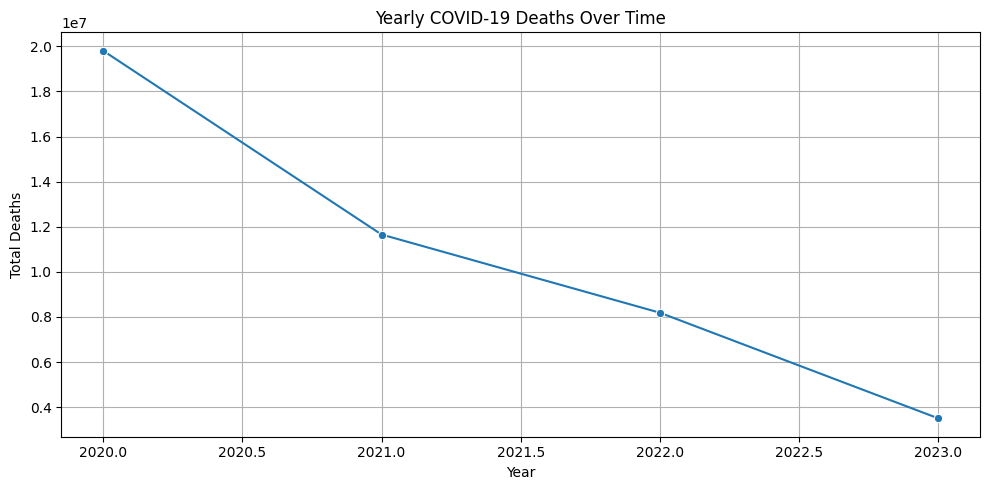

In [13]:
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['Year'] = df['Start Date'].dt.year
yearly_df = df.groupby('Year')['COVID-19 Deaths'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_df, x='Year', y='COVID-19 Deaths', marker='o')
plt.title("Yearly COVID-19 Deaths Over Time")
plt.ylabel("Total Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()

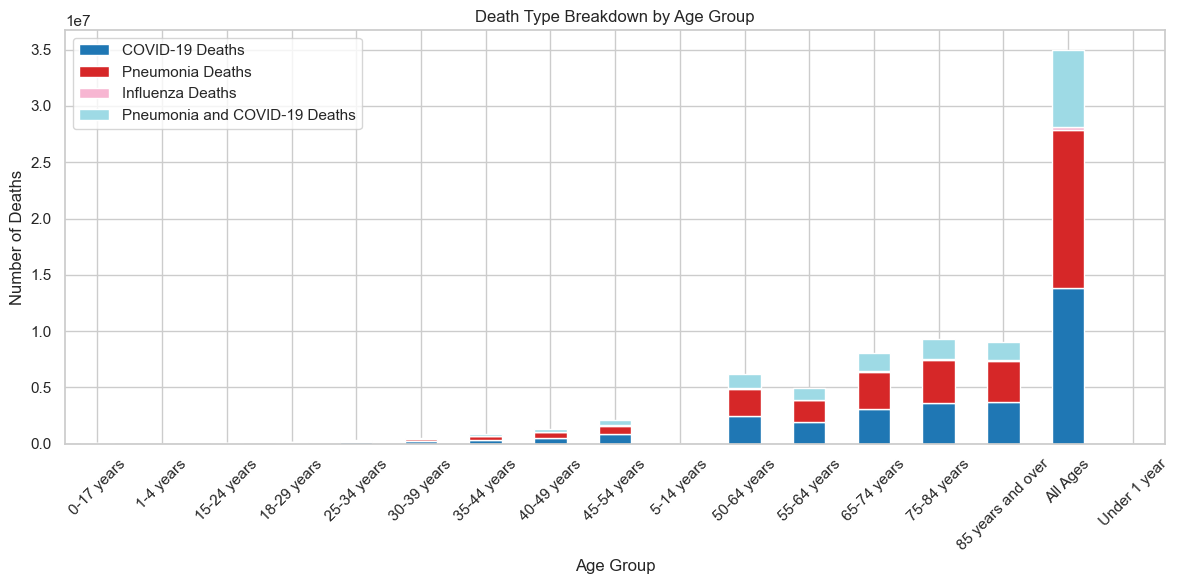

In [58]:
stacked_df = df.groupby('Age Group')[['COVID-19 Deaths', 'Pneumonia Deaths', 'Influenza Deaths', 'Pneumonia and COVID-19 Deaths']].sum().reset_index()
stacked_df.set_index('Age Group').plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title("Death Type Breakdown by Age Group")
plt.ylabel("Number of Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

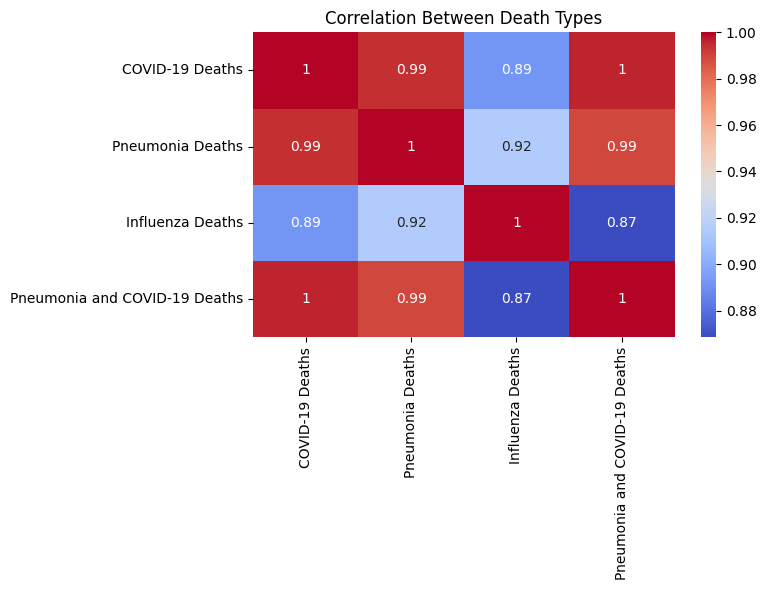

In [16]:
death_corr = df[['COVID-19 Deaths', 'Pneumonia Deaths', 'Influenza Deaths', 'Pneumonia and COVID-19 Deaths']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(death_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Death Types")
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_16052\3935505976.py:29: UserWarning: Glyph 127874 (\N{BIRTHDAY CAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127874 (\N{BIRTHDAY CAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


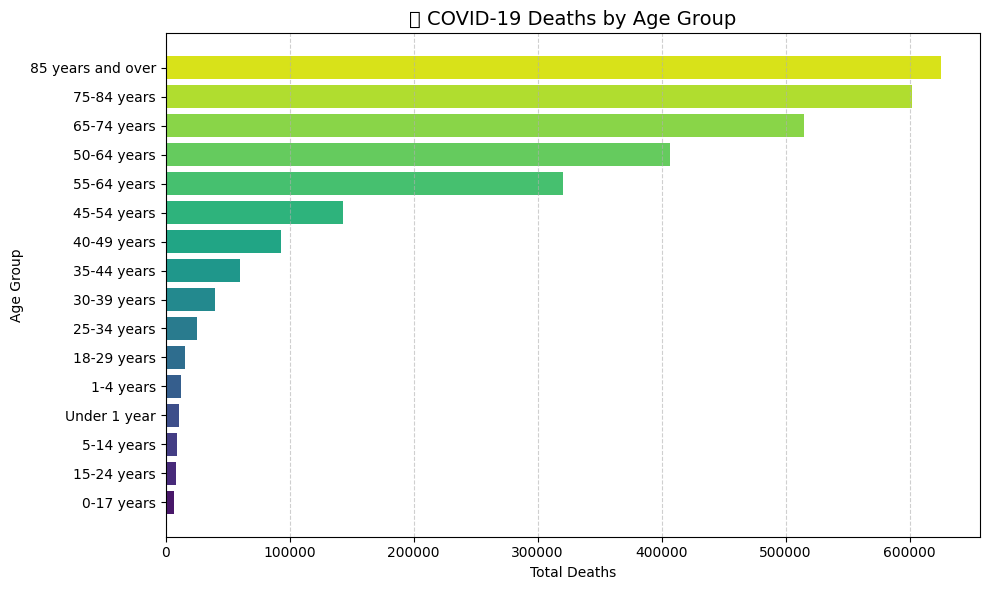

In [12]:
# 🎂 Top Age Groups (Clean & Professional - No Values)

# 🔹 Filter to avoid double counting
age_df = df[
    (df['Sex'] == 'All Sexes') & 
    (df['Age Group'] != 'All Ages') & 
    (df['Group'] == 'By Total')
]

# 🔹 Grouping
age_df = age_df.groupby('Age Group')['COVID-19 Deaths'].sum().sort_values(ascending=True)

# 🔹 Plot
plt.figure(figsize=(10,6))

# Professional color palette
colors = sns.color_palette("viridis", len(age_df))

plt.barh(age_df.index, age_df.values, color=colors)

# 🔹 Titles & Labels
plt.title("🎂 COVID-19 Deaths by Age Group", fontsize=14)
plt.xlabel("Total Deaths")
plt.ylabel("Age Group")

# Grid for clean look
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [18]:
top_states = df.groupby('State')['COVID-19 Deaths'].sum().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(top_states, x='State', y='COVID-19 Deaths', color='COVID-19 Deaths', title="Top 10 States by COVID-19 Deaths")
fig.show()
sex_dist = df.groupby('Sex')['COVID-19 Deaths'].sum().reset_index()

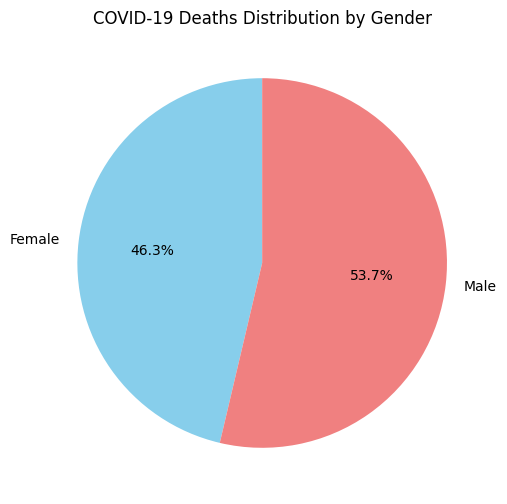

In [19]:
filtered_df = df[df['Sex'].isin(['Male', 'Female'])]
gender_deaths = filtered_df.groupby('Sex')['COVID-19 Deaths'].sum()
gender_deaths.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6,6), colors=['skyblue', 'lightcoral'])
plt.title("COVID-19 Deaths Distribution by Gender")
plt.ylabel("")
plt.show()


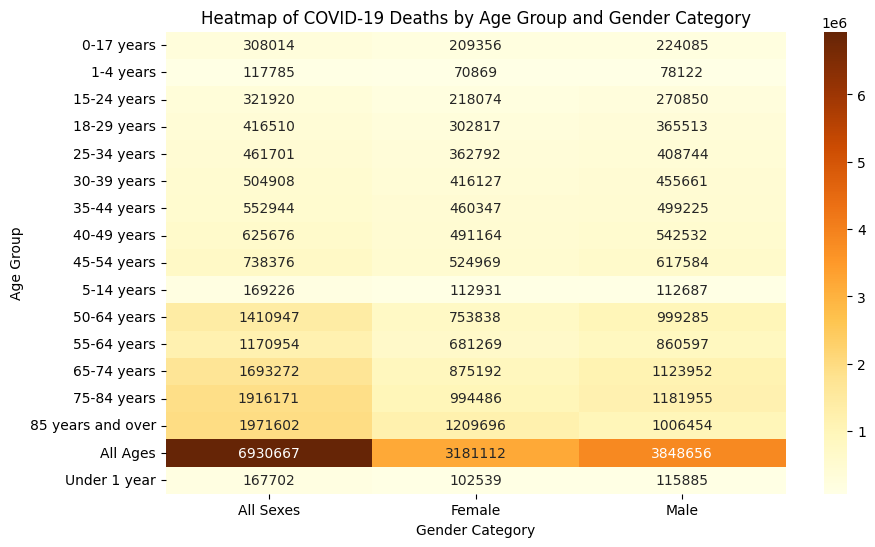

In [20]:
data = df.pivot_table(values='COVID-19 Deaths', index='Age Group', columns='Sex', aggfunc='sum')
plt.figure(figsize=(10, 6))
sns.heatmap(data, annot=True, fmt=".0f", cmap="YlOrBr")
plt.title("Heatmap of COVID-19 Deaths by Age Group and Gender Category")
plt.ylabel("Age Group")
plt.xlabel("Gender Category")
plt.show()

In [21]:
df['Sex_encoded'] = df['Sex'].map({'Male': 0, 'Female': 1})
sex_dist = df.groupby('Sex_encoded')['COVID-19 Deaths'].sum().reset_index()


X = sex_dist[['Sex_encoded']]  # independent variable
y = sex_dist['COVID-19 Deaths']  # dependent variable

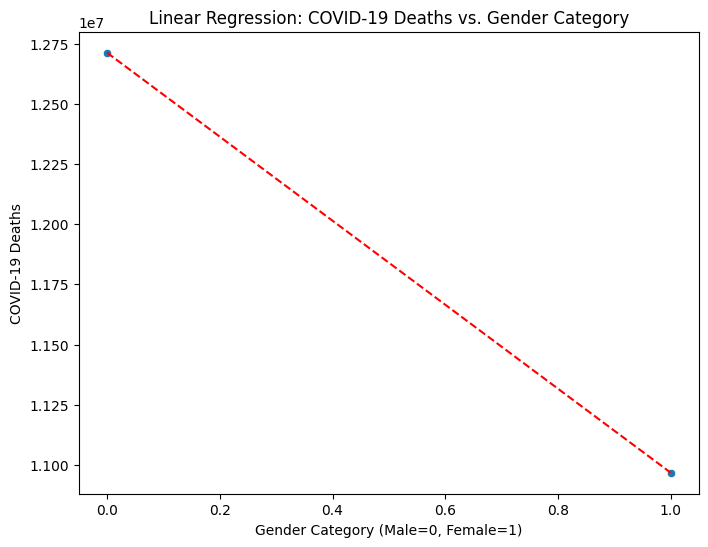

In [22]:
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Sex_encoded', y='COVID-19 Deaths', data=sex_dist)
plt.plot(X, y_pred, color='red', linestyle='--')
plt.title('Linear Regression: COVID-19 Deaths vs. Gender Category')
plt.xlabel('Gender Category (Male=0, Female=1)')
plt.ylabel('COVID-19 Deaths')
plt.show()